In [112]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import random
import scipy.stats as stats
import tensorflow as tf
import warnings

from rembg import remove
from scipy.signal import find_peaks
from skimage.color import rgb2gray
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from skimage.feature import hog
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix, roc_curve, roc_auc_score, auc
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import label_binarize
from sklearn.svm import SVC
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tqdm.notebook import tqdm

warnings.filterwarnings("ignore")
seed = 1234

## Data Prep

### Read in Data

In [2]:
# Loading training, testing, and validation directories
train_dir = 'C:/Ubuntu_files/w281/project/Train'
test_dir = 'C:/Ubuntu_files/w281/project/Test'
val_dir = 'C:/Ubuntu_files/w281/project/Validation'

In [3]:
train = tf.keras.utils.image_dataset_from_directory(
    train_dir,  # Directory where the Training images are located
    labels = 'inferred', # Classes will be inferred according to the structure of the directory
    label_mode = 'int',
    class_names = ['Healthy', 'Powdery', 'Rust'],
    batch_size = 16,    # Number of processed samples before updating the model's weights
    image_size = (256, 256), # Defining a fixed dimension for all images
    shuffle = False,  # Shuffling data
    seed = seed,  # Random seed for shuffling and transformations
    validation_split = 0, # We don't need to create a validation set from the training set
    crop_to_aspect_ratio = True # Resize images without aspect ratio distortion
)

Found 1322 files belonging to 3 classes.


In [4]:
test = tf.keras.utils.image_dataset_from_directory(
    test_dir,  
    labels = 'inferred', 
    label_mode = 'int',
    class_names = ['Healthy', 'Powdery', 'Rust'],
    batch_size = 16,    
    image_size = (256, 256), 
    shuffle = False,  
    seed = seed,  
    validation_split = 0, 
    crop_to_aspect_ratio = True 
)

Found 150 files belonging to 3 classes.


In [5]:
validation = tf.keras.utils.image_dataset_from_directory(
    val_dir,  
    labels = 'inferred', 
    label_mode = 'int',
    class_names = ['Healthy', 'Powdery', 'Rust'],
    batch_size = 16,    
    image_size = (256, 256),
    shuffle = False,  
    seed = seed,  
    validation_split = 0, 
    crop_to_aspect_ratio = True 
)

Found 60 files belonging to 3 classes.


### Process Data

In [6]:
train_images = np.concatenate([np.round(x.numpy()).astype(np.uint8) for x, _ in train]) #rembg requires uint8 dtype
train_labels = np.concatenate([y.numpy() for _, y in train])

val_images = np.concatenate([np.round(x.numpy()).astype(np.uint8) for x, _ in validation])
val_labels = np.concatenate([y.numpy() for _, y in validation])

test_images = np.concatenate([np.round(x.numpy()).astype(np.uint8) for x, _ in test])
test_labels = np.concatenate([y.numpy() for _, y in test])

In [ ]:
train_images_processed = np.stack([np.array(remove(image))[:, :, :3] for image in tqdm(train_images)]) #remove alpha channel

In [ ]:
val_images_processed = np.stack([np.array(remove(image))[:, :, :3] for image in tqdm(val_images)])

In [ ]:
test_images_processed = np.stack([np.array(remove(image))[:, :, :3] for image in tqdm(test_images)])

In [ ]:
np.savez_compressed("train.npz",
        IMAGES=train_images_processed)

np.savez_compressed("val.npz",
        IMAGES=val_images_processed)

np.savez_compressed("test.npz",
        IMAGES=test_images_processed)

In [7]:
with np.load("train.npz") as train_data:
    train_images_processed = train_data['IMAGES']
with np.load("val.npz") as validate_data:
    val_images_processed = validate_data['IMAGES']
with np.load("test.npz") as test_data:
    test_images_processed = test_data['IMAGES']

## EDA

In [58]:
# create table for data-set sizes and shape

splits = {
    "Training": train_images,
    "Validation": val_images,
    "Test": test_images
}

rows = []
for name, arr in splits.items():
    rows.append({
        "Split": name,
        "# Samples": arr.shape[0],
        "Image Shape": arr.shape[1:3],
        "Channels": arr.shape[3] if arr.ndim == 4 else 1,
        "Dtype": arr.dtype
    })

df = pd.DataFrame(rows)
print(df)

        Split  # Samples Image Shape  Channels  Dtype
0    Training       1322  (256, 256)         3  uint8
1  Validation         60  (256, 256)         3  uint8
2        Test        150  (256, 256)         3  uint8


In [59]:
# look at pixel intensity ranges
print("Train min/max:", train_images.min(), train_images.max())
print("Val min/max:", val_images.min(), val_images.max())
print("Test min/max:", test_images.min(), test_images.max())

Train min/max: 0 255
Val min/max: 0 255
Test min/max: 0 255


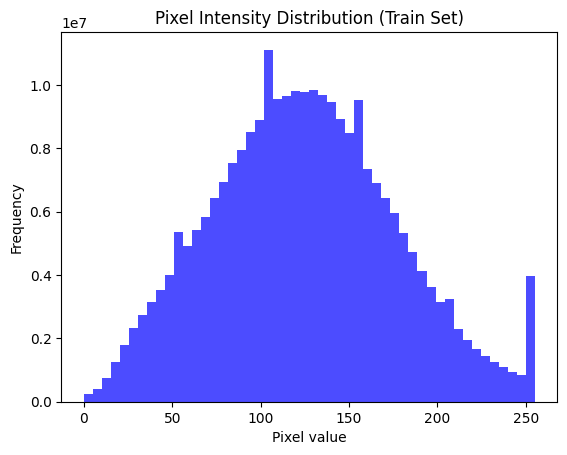

In [60]:
# plot pixel intensity distributions

plt.hist(train_images.ravel(), bins=50, color='blue', alpha=0.7)
plt.title("Pixel Intensity Distribution (Train Set)")
plt.xlabel("Pixel value")
plt.ylabel("Frequency")
plt.show()

In [61]:
# look at image intensity differences beteween classes

for label in np.unique(train_labels):
    class_imgs = train_images[train_labels == label]
    print(f"Class {class_names[label]}: mean={class_imgs.mean():.2f}, std={class_imgs.std():.2f}")

Class Healthy: mean=122.99, std=53.97
Class Powdery: mean=134.48, std=46.82
Class Rust: mean=117.34, std=52.57


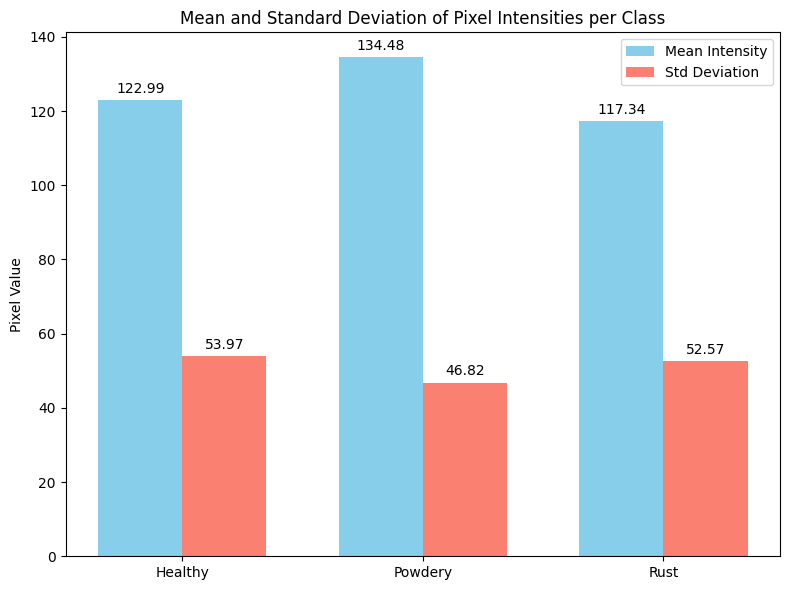

In [62]:
# plot image intensity differences
means = []
stds = []

for label in np.unique(train_labels):
    class_imgs = train_images[train_labels == label]
    means.append(class_imgs.mean())
    stds.append(class_imgs.std())

# Plot side-by-side bar charts
x = np.arange(len(class_names))  # positions
width = 0.35

fig, ax = plt.subplots(figsize=(8,6))
bars1 = ax.bar(x - width/2, means, width, label='Mean Intensity', color='skyblue')
bars2 = ax.bar(x + width/2, stds, width, label='Std Deviation', color='salmon')

ax.set_xticks(x)
ax.set_xticklabels(class_names)
ax.set_ylabel("Pixel Value")
ax.set_title("Mean and Standard Deviation of Pixel Intensities per Class")
ax.legend()

# Annotate bars
for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0,3), textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

## Feature Extraction

### Blob Count and Blob Area

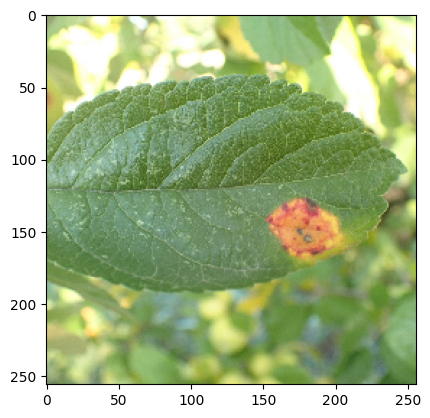

In [8]:
plt.imshow(train_images[1296])

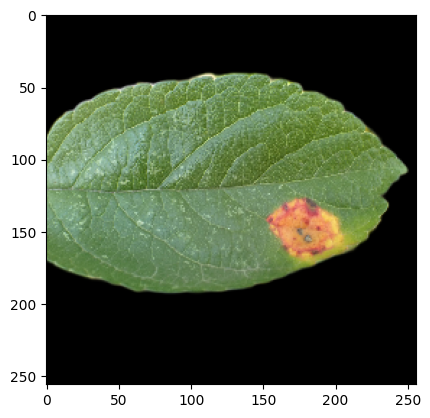

In [9]:
plt.imshow(train_images_processed[1296])

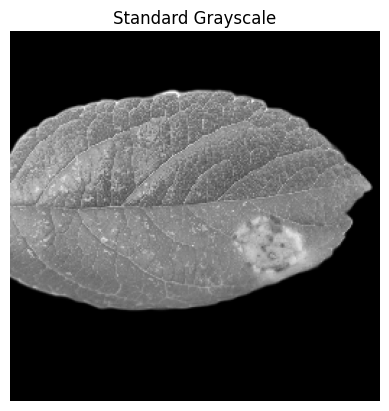

In [75]:
plt.imshow(cv2.cvtColor(train_images_processed[1296], cv2.COLOR_RGB2GRAY), cmap='gray')
plt.title("Standard Grayscale")
plt.axis("off")
plt.show()

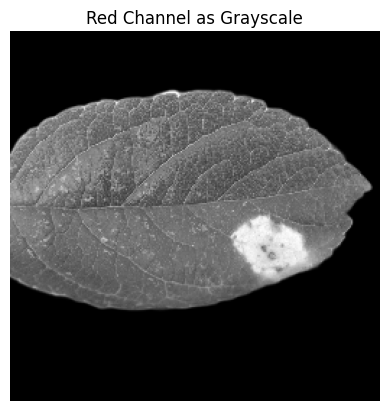

In [76]:
plt.imshow(train_images_processed[1296][:, :, 0], cmap='gray')
plt.title("Red Channel as Grayscale")
plt.axis("off")
plt.show()

95


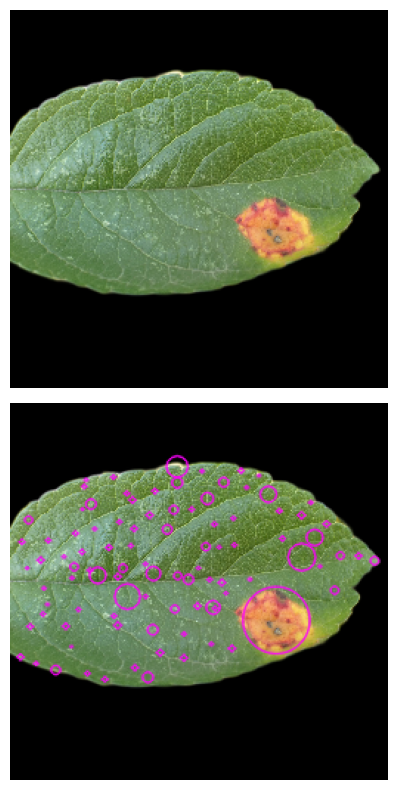

In [84]:
img = train_images_processed[1296].copy()

gray_img = img[:, :, 0]

# Setup SimpleBlobDetector parameters
params = cv2.SimpleBlobDetector_Params()

# Example parameter tuning (adjust as needed for your blobs)
params.filterByColor = True
params.blobColor = 255           # Use 0 for dark blobs, 255 for light blobs
params.filterByArea = True
params.minArea = 1              # minimum area of blob
params.maxArea = 5000            # maximum area of blob
params.filterByCircularity = False
params.filterByConvexity = False
params.filterByInertia = False

detector = cv2.SimpleBlobDetector_create(params)
blobs = detector.detect(gray_img)
print(len(blobs))

output = img.copy()
output_with_blobs = cv2.drawKeypoints(
    output,
    blobs,
    np.array([]),
    (255,0,255),
    cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)


fig, axs = plt.subplots(2, 1, figsize=(12,8))
#axs[0].set_title("Blob Detection ")
axs[0].imshow(img)
axs[0].axis('off')

axs[1].imshow(cv2.cvtColor(output_with_blobs, cv2.COLOR_BGR2RGB))
axs[1].imshow(output_with_blobs)
axs[1].axis('off')

plt.tight_layout()
plt.show()

In [13]:
def count_blobs(images, params):
    blob_counts = []
    blob_areas = []
    
    # Create the detector
    detector = cv2.SimpleBlobDetector_create(params)

    for i in range(len(images)):
        img = images[i].copy()

        #gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        gray_img = img[:, :, 0]

        # Detect blobs
        blobs = detector.detect(gray_img)

        blob_count = len(blobs)
        total_area = 0

        if blobs is not None:
            for blob in blobs:
                total_area += np.pi * ((blob.size / 2) ** 2) #blob.size is blob diameter
                
        blob_counts.append(blob_count)
        blob_areas.append(total_area)
        
    return np.array(blob_counts), np.array(blob_areas)

In [14]:
# Setup SimpleBlobDetector parameters
params = cv2.SimpleBlobDetector_Params()

# Example parameter tuning (adjust as needed for your blobs)
params.filterByColor = True
params.blobColor = 255           # Use 0 for dark blobs, 255 for light blobs
params.filterByArea = True
params.minArea = 1              # minimum area of blob
params.maxArea = 5000            # maximum area of blob
params.filterByCircularity = False
params.filterByConvexity = False
params.filterByInertia = False

train_blobs, train_blob_area = count_blobs(train_images_processed, params)
val_blobs, val_blob_area = count_blobs(val_images_processed, params)
test_blobs, test_blob_area = count_blobs(test_images_processed, params)

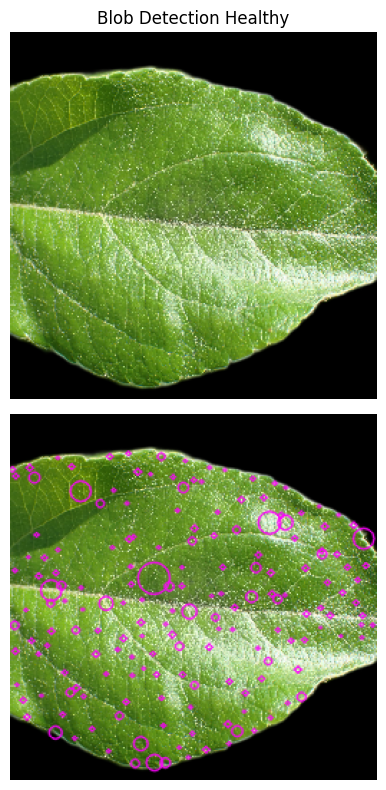

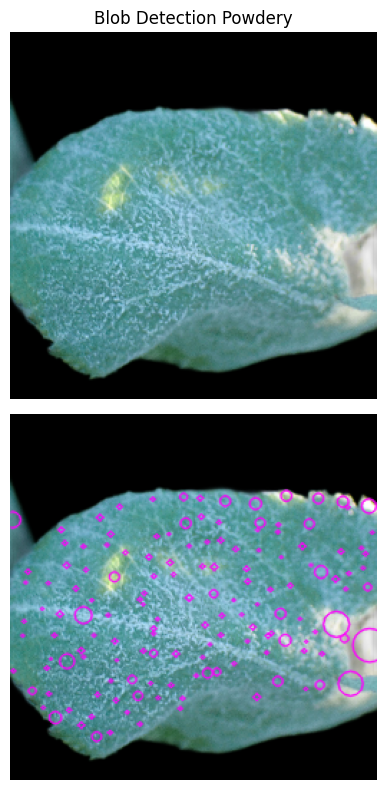

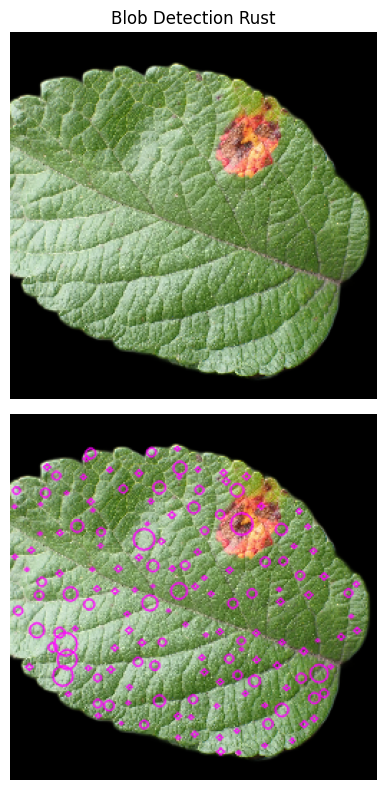

In [15]:
for i, label in enumerate(['Healthy', 'Powdery', 'Rust']):
    filt_data = train_blobs[train_labels == i]
    filt_images = train_images_processed[train_labels == i]

    #plot case with most circles per class
    image = filt_images[np.argmax(filt_data)].copy() #find max count image

    #gray_img = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    gray_img = image[:, :, 0]

    # Detect blobs (keypoints)
    detector = cv2.SimpleBlobDetector_create(params)

    #blobs = detector.detect(rounded_gray_image)
    blobs = detector.detect(gray_img)

    output = image.copy()
    output_with_blobs = cv2.drawKeypoints(
        output,
        blobs,
        np.array([]),
        (255,0,255),
        cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
    )
    

    fig, axs = plt.subplots(2, 1, figsize=(12,8))
    axs[0].set_title("Blob Detection " + label)
    axs[0].imshow(image)
    axs[0].axis('off')

    axs[1].imshow(cv2.cvtColor(output_with_blobs, cv2.COLOR_BGR2RGB))
    axs[1].imshow(output_with_blobs)
    axs[1].axis('off')

    plt.tight_layout()
    plt.show()

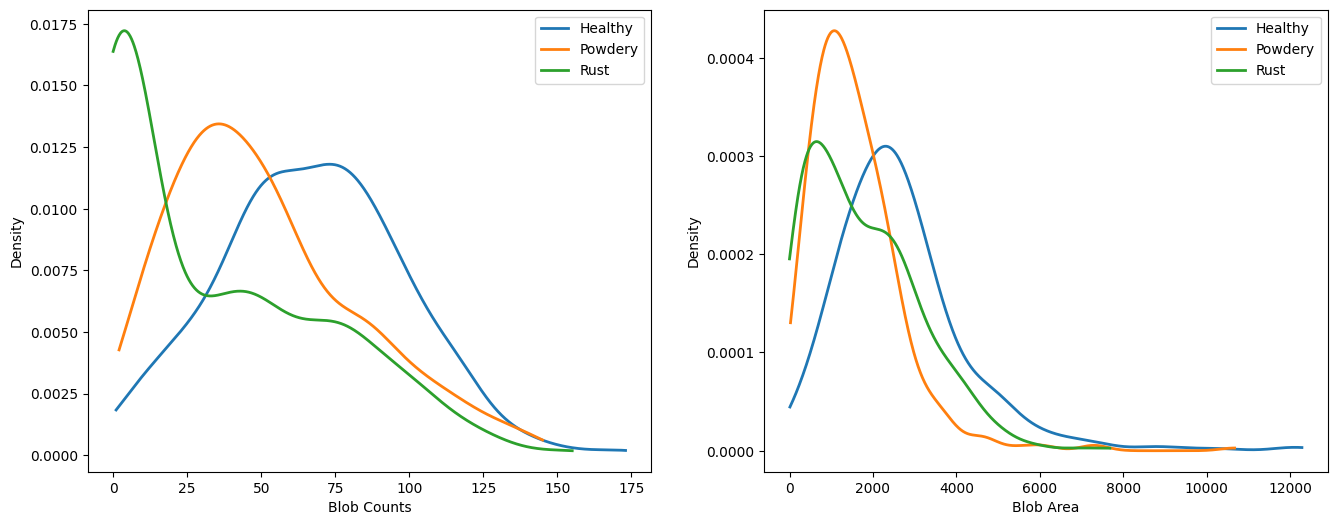

In [85]:
fig, axs = plt.subplots(1, 2, figsize=(16,6))
#axs[0].set_title('Blob Count Smoothed Histogram per Class')
axs[0].set_xlabel('Blob Counts')
axs[0].set_ylabel('Density')

#axs[1].set_title('Total Blob Area Smoothed Histogram per Class')
axs[1].set_xlabel('Blob Area')
axs[1].set_ylabel('Density')

for i, label in enumerate(['Healthy', 'Powdery', 'Rust']):
    class_blobs = train_blobs[train_labels == i]
    class_areas = train_blob_area[train_labels == i]

    # Create an array of x-values for the smooth curve
    blob_x = np.linspace(class_blobs.min(), class_blobs.max(), 1000)
    area_x = np.linspace(class_areas.min(), class_areas.max(), 1000)

    # Calculate the KDE
    blob_kde = stats.gaussian_kde(class_blobs)
    area_kde = stats.gaussian_kde(class_areas)

    axs[0].plot(blob_x, blob_kde(blob_x), linewidth=2, label=label)
    axs[1].plot(area_x, area_kde(area_x), linewidth=2, label=label)

axs[0].legend()
axs[1].legend()
plt.show()

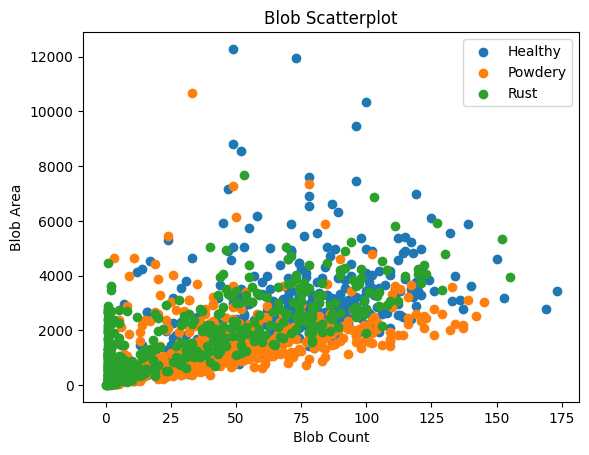

In [17]:
for i, label in enumerate(['Healthy', 'Powdery', 'Rust']):
    class_blobs = train_blobs[train_labels == i]
    class_areas = train_blob_area[train_labels == i]

    plt.scatter(class_blobs, class_areas, label=label)

plt.title('Blob Scatterplot')
plt.xlabel('Blob Count')
plt.ylabel('Blob Area')
plt.legend()
plt.show()

### Luminance Histogram

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

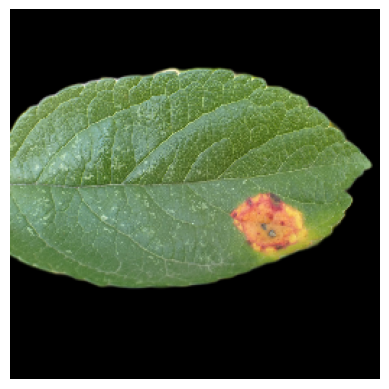

In [77]:
plt.imshow(train_images_processed[1296])
plt.axis("off")

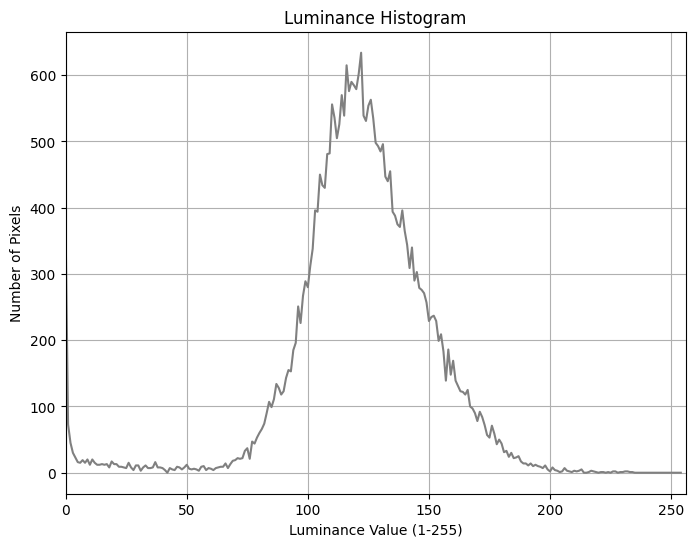

In [19]:
lumin_hist = cv2.calcHist([cv2.cvtColor(train_images_processed[1296], cv2.COLOR_BGR2GRAY)], [0], None, [255], [1, 256])

# Plot the histogram
plt.figure(figsize=(8, 6))
plt.title("Luminance Histogram")
plt.xlabel("Luminance Value (1-255)")
plt.ylabel("Number of Pixels")
plt.plot(lumin_hist, color='gray')
plt.xlim([0, 256])
plt.grid(True)
plt.show()

In [20]:
def luminance(images):
    return np.stack([cv2.calcHist([cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)], [0], None, [255], [1, 256]).flatten().astype(int) for image in images])

In [21]:
train_lumin = luminance(train_images_processed)
val_lumin = luminance(val_images_processed)
test_lumin = luminance(test_images_processed)

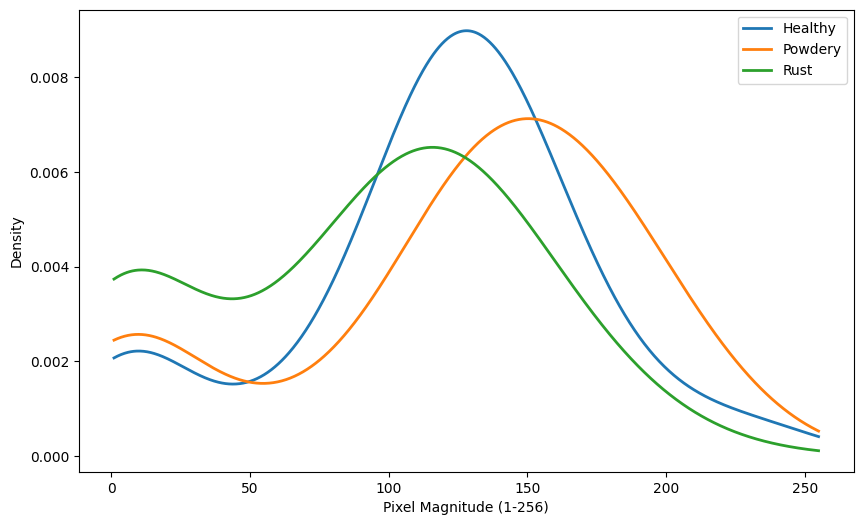

In [86]:
fig, ax = plt.subplots(figsize=(10, 6))

#ax.set_title('Luminance Smoothed Histogram per Class')
ax.set_xlabel('Pixel Magnitude (1-256)')
ax.set_ylabel('Density')

class_names = ['Healthy', 'Powdery', 'Rust']

for i, label in enumerate(class_names):
    # Select luminance histograms for this class: shape (n_samples, n_bins)
    class_lumin = train_lumin[train_labels == i]

    # Aggregate histograms across images in this class
    hist_sum = class_lumin.sum(axis=0)  # shape (n_bins,)

    bin_centers = np.arange(1, 256)

    # KDE over bin centers, weighted by counts in each bin
    kde = stats.gaussian_kde(bin_centers, weights=hist_sum)

    # Smooth curve grid
    x = np.linspace(1, 255, 1000)
    ax.plot(x, kde(x), linewidth=2, label=label)

ax.legend()
plt.show()

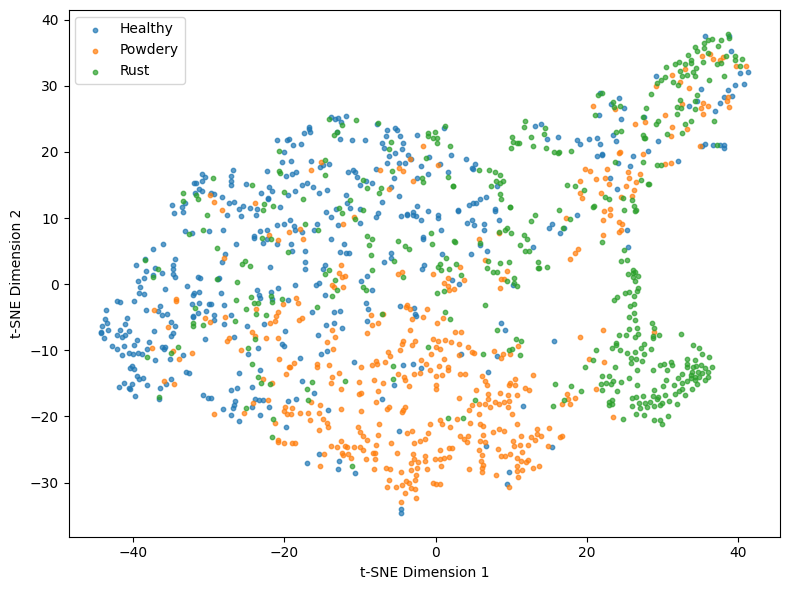

In [87]:
tsne = TSNE(
    n_components=2,
    perplexity=30,      # tune if needed (5–50 often reasonable)
    learning_rate='auto',
    init='random',
    random_state=seed
)
X_embedded = tsne.fit_transform(train_lumin)  # shape: (n_samples, 2)

# Plot
plt.figure(figsize=(8, 6))
class_names = ['Healthy', 'Powdery', 'Rust']

for i, name in enumerate(class_names):
    mask = (train_labels == i)
    plt.scatter(
        X_embedded[mask, 0],
        X_embedded[mask, 1],
        s=10,
        alpha=0.7,
        label=name
    )

#plt.title('t-SNE of Luminance Histograms (Train Set)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend()
plt.tight_layout()
plt.show()

### Color Summary

In [24]:
def gen_color_hist(img):
    red_hist, _ = np.histogram(img[:, :, 0].flatten(), bins=255, range=(1, 256))
    green_hist, _ = np.histogram(img[:, :, 1].flatten(), bins=255, range=(1, 256))
    blue_hist, _ = np.histogram(img[:, :, 2].flatten(), bins=255, range=(1, 256))
    return {'red': red_hist, 'green': green_hist, 'blue': blue_hist}

def calculate_mean(histogram):
    return np.sum(np.arange(255) * histogram) / np.sum(histogram)

def calculate_std(histogram):
    mean = calculate_mean(histogram)
    variance = np.sum(((np.arange(255) - mean) ** 2) * histogram) / np.sum(histogram)
    return np.sqrt(variance)

def calculate_skewness(histogram):
    mean = calculate_mean(histogram)
    std = calculate_std(histogram)
    if std == 0:
        return 0
    return np.sum((((np.arange(255) - mean) / std) ** 3) * histogram) / np.sum(histogram)

def calculate_median(histogram):
    cumulative = np.cumsum(histogram)
    return float(np.argmax(cumulative >= np.sum(histogram) / 2.0))

def calculate_entropy(histogram):
    probabilities = (histogram + 1e-10) / np.sum(histogram)
    return -np.sum(probabilities * np.log2(probabilities))

def calculate_peak_count(histogram):
    peaks, _ = find_peaks(histogram, prominence=0.05 * np.max(histogram))
    return len(peaks)

def extract_color_histogram_features(images):
    all_features = []

    for img in images:
        hist_data = gen_color_hist(img)
        features = []

        for channel in ['red', 'green', 'blue']:
            histogram = hist_data[channel]
            features.append(calculate_mean(histogram))
            features.append(calculate_std(histogram))
            features.append(calculate_skewness(histogram))
            features.append(calculate_median(histogram))
            features.append(calculate_entropy(histogram))
            features.append(calculate_peak_count(histogram))

        all_features.append(features)

    return np.array(all_features)

In [25]:
train_color_features = extract_color_histogram_features(train_images_processed)
val_color_features = extract_color_histogram_features(val_images_processed)
test_color_features = extract_color_histogram_features(test_images_processed)

print(f"Color features shape: {train_color_features.shape}")  # expecting (1322, 18)

Color features shape: (1322, 18)


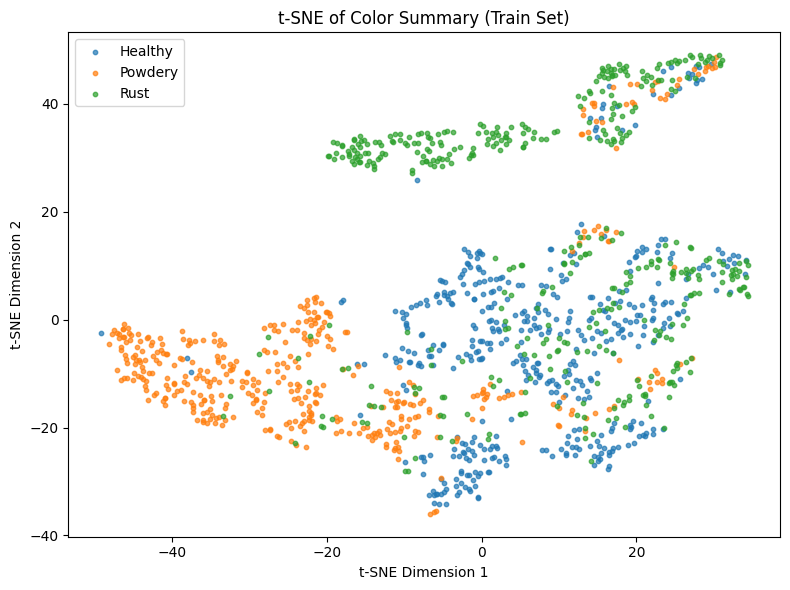

In [26]:
tsne = TSNE(
    n_components=2,
    perplexity=30,      # tune if needed (5–50 often reasonable)
    learning_rate='auto',
    init='random',
    random_state=seed
)
X_embedded = tsne.fit_transform(train_color_features)  # shape: (n_samples, 2)

# Plot
plt.figure(figsize=(8, 6))
class_names = ['Healthy', 'Powdery', 'Rust']

for i, name in enumerate(class_names):
    mask = (train_labels == i)
    plt.scatter(
        X_embedded[mask, 0],
        X_embedded[mask, 1],
        s=10,
        alpha=0.7,
        label=name
    )

plt.title('t-SNE of Color Summary (Train Set)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend()
plt.tight_layout()
plt.show()

### HOG

In [27]:
# load images from preprocessed array and extract HOG features
def load_hog_data(images, labels, visualize=False, max_visualize=5):
    features, out_labels = [], []
    class_features = {}

    class_names = ["Healthy", "Powdery", "Rust"]
    labels = np.array([class_names[int(i)] for i in labels])

    # convert to grayscale
    images_gray = rgb2gray(images / 255.0)

    # loop over class labels
    unique_labels = np.unique(labels)

    for label in unique_labels:

        class_features[label] = []

        visualize_count = 0
        imgs_to_show, hots_to_show = [], []

        # get indices of this class
        idxs = np.where(labels == label)[0]

        for idx in idxs:
            img_resized = images_gray[idx]

            # visualize only first max_visualize images per class
            vis = visualize and visualize_count < max_visualize

            if vis:
                f, h = hog(
                    img_resized,
                    orientations=3,
                    pixels_per_cell=(10,10),
                    cells_per_block=(2,2),
                    visualize=True
                )
                imgs_to_show.append(img_resized)
                hots_to_show.append(h)
                visualize_count += 1
            else:
                f = hog(
                    img_resized,
                    orientations=3,
                    pixels_per_cell=(10,10),
                    cells_per_block=(2,2),
                    visualize=False
                )

            features.append(f)
            out_labels.append(label)
            class_features[label].append(f)

        # plot images and HOGs
        if visualize_count > 0:
            n = len(imgs_to_show)
            fig, axs = plt.subplots(2, n, figsize=(3*n,6))
            for i in range(n):
                axs[0,i].imshow(imgs_to_show[i], cmap='gray')
                axs[0,i].axis('off')
                axs[0,i].set_title(f'{label} {i+1}')
                axs[1,i].imshow(hots_to_show[i], cmap='gray')
                axs[1,i].axis('off')
            plt.tight_layout()
            plt.show()

    # plot HOG feature vectors
    if visualize:
        plt.figure(figsize=(10, 5))
        for label, feats in class_features.items():
            feats_array = np.array(feats)
            mean_feat = feats_array.mean(axis=0)
            plt.plot(mean_feat, alpha=0.8, label=label)

        plt.title("HOG Feature Vector Plot per Class")
        plt.xlabel("Feature Position Index")
        plt.ylabel("Feature Value")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return np.array(features), np.array(out_labels)

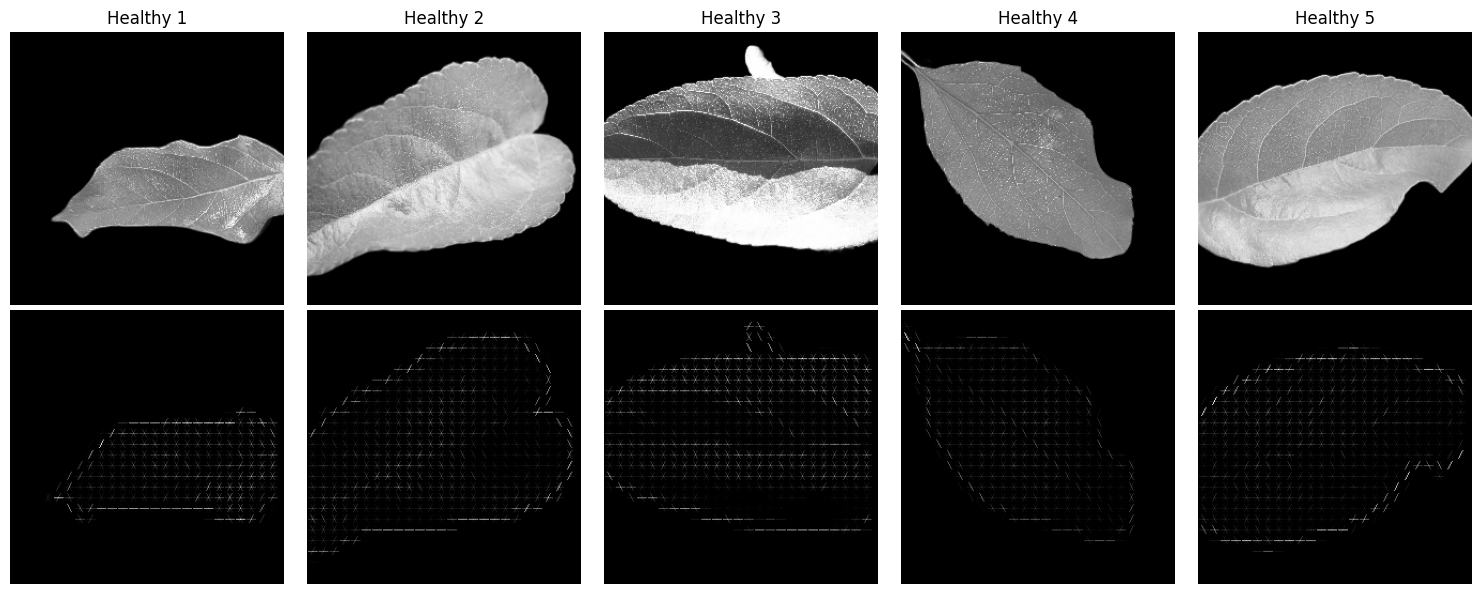

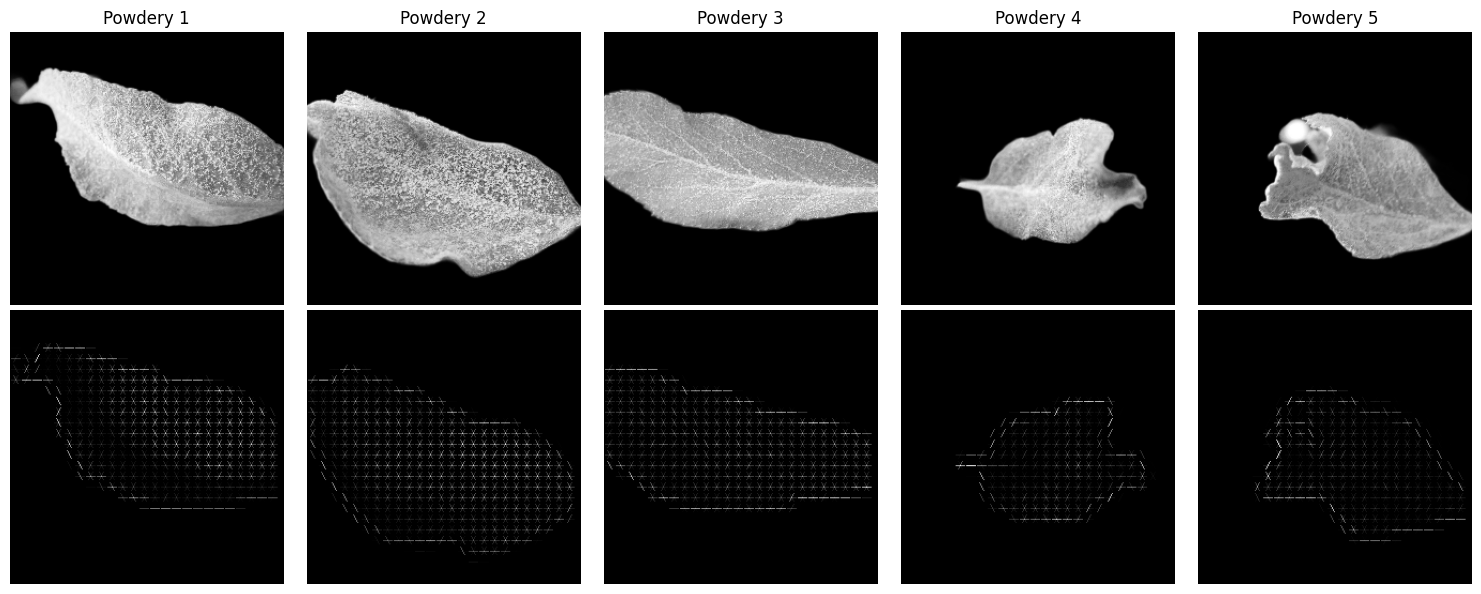

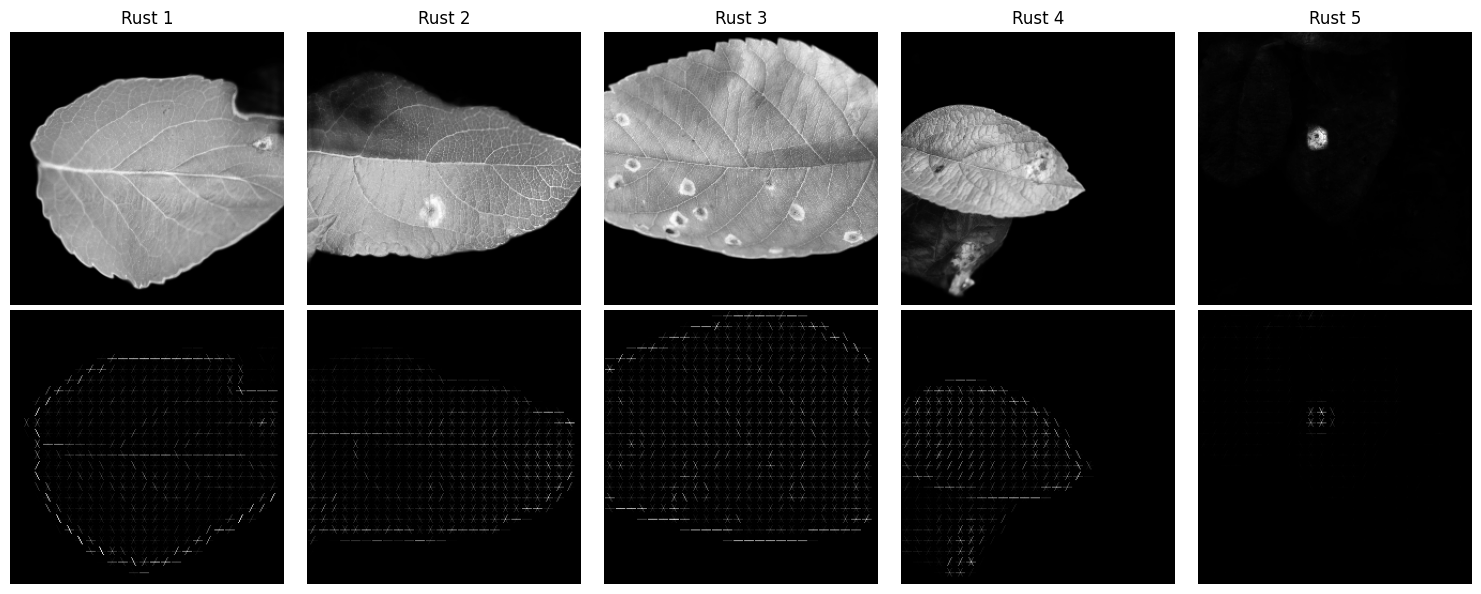

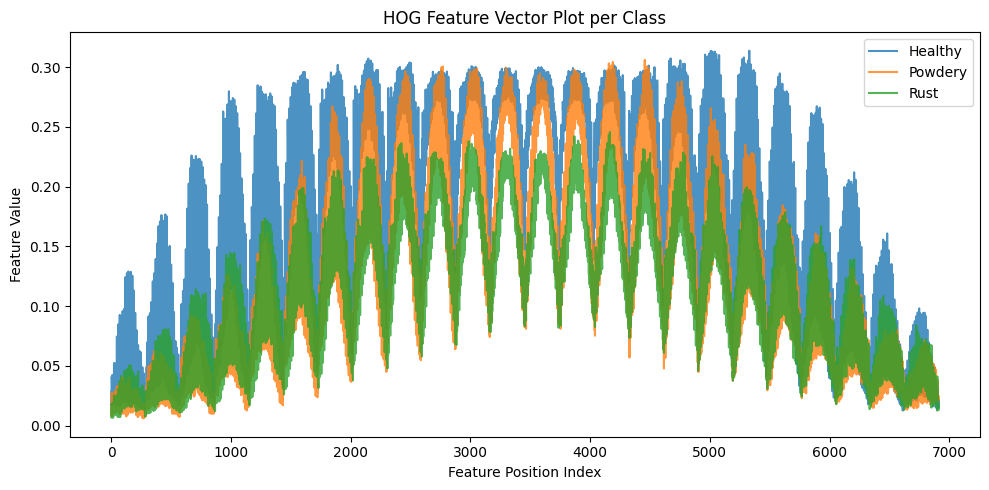

Train dataset: 1322 samples, 3 classes.
Validation dataset: 60 samples, 3 classes.
Test dataset: 150 samples, 3 classes.


In [28]:
train_texture_features, train_texture_labels = load_hog_data(train_images_processed, train_labels, visualize=True, max_visualize=5)
valid_texture_features, valid_texture_labels = load_hog_data(val_images_processed, val_labels)
test_texture_features, test_texture_labels = load_hog_data(test_images_processed, test_labels)

# apply PCA
pca = PCA(n_components=100)
train_texture_features = pca.fit_transform(train_texture_features)
valid_texture_features = pca.transform(valid_texture_features)
test_texture_features  = pca.transform(test_texture_features)

print(f"Train dataset: {train_texture_features.shape[0]} samples, {len(set(train_texture_labels))} classes.")
print(f"Validation dataset: {valid_texture_features.shape[0]} samples, {len(set(valid_texture_labels))} classes.")
print(f"Test dataset: {test_texture_features.shape[0]} samples, {len(set(test_texture_labels))} classes.")

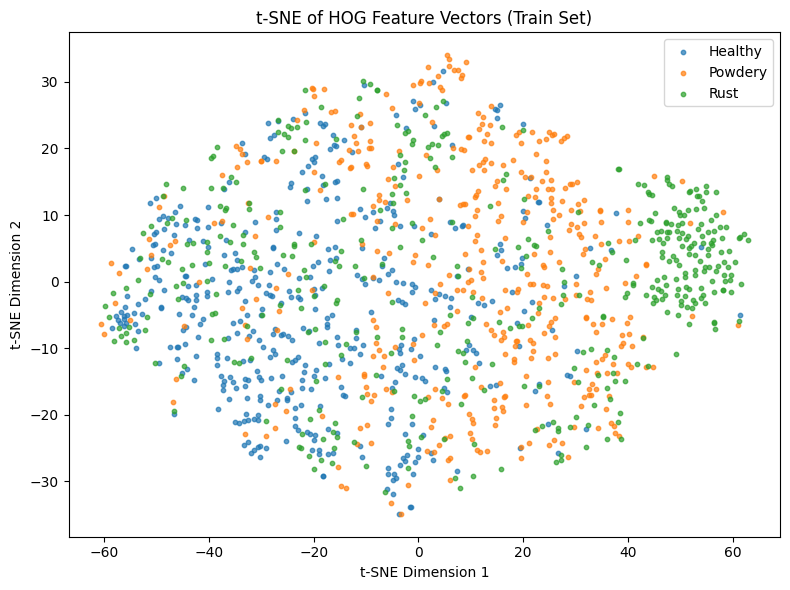

In [98]:
tsne = TSNE(
    n_components=2,
    perplexity=30,        # 5–50 usually reasonable
    learning_rate='auto',
    init='random',
    random_state=seed
)

# Input: (N_samples, 2048)
X_embedded = tsne.fit_transform(train_texture_features)

# ================================
# Plotting
# ================================
plt.figure(figsize=(8, 6))
class_names = ['Healthy', 'Powdery', 'Rust']

for i, name in enumerate(class_names):
    mask = (train_labels == i)
    plt.scatter(
        X_embedded[mask, 0],
        X_embedded[mask, 1],
        s=10,
        alpha=0.7,
        label=name
    )

plt.title('t-SNE of HOG Feature Vectors (Train Set)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend()
plt.tight_layout()
plt.show()

### Edge Detection

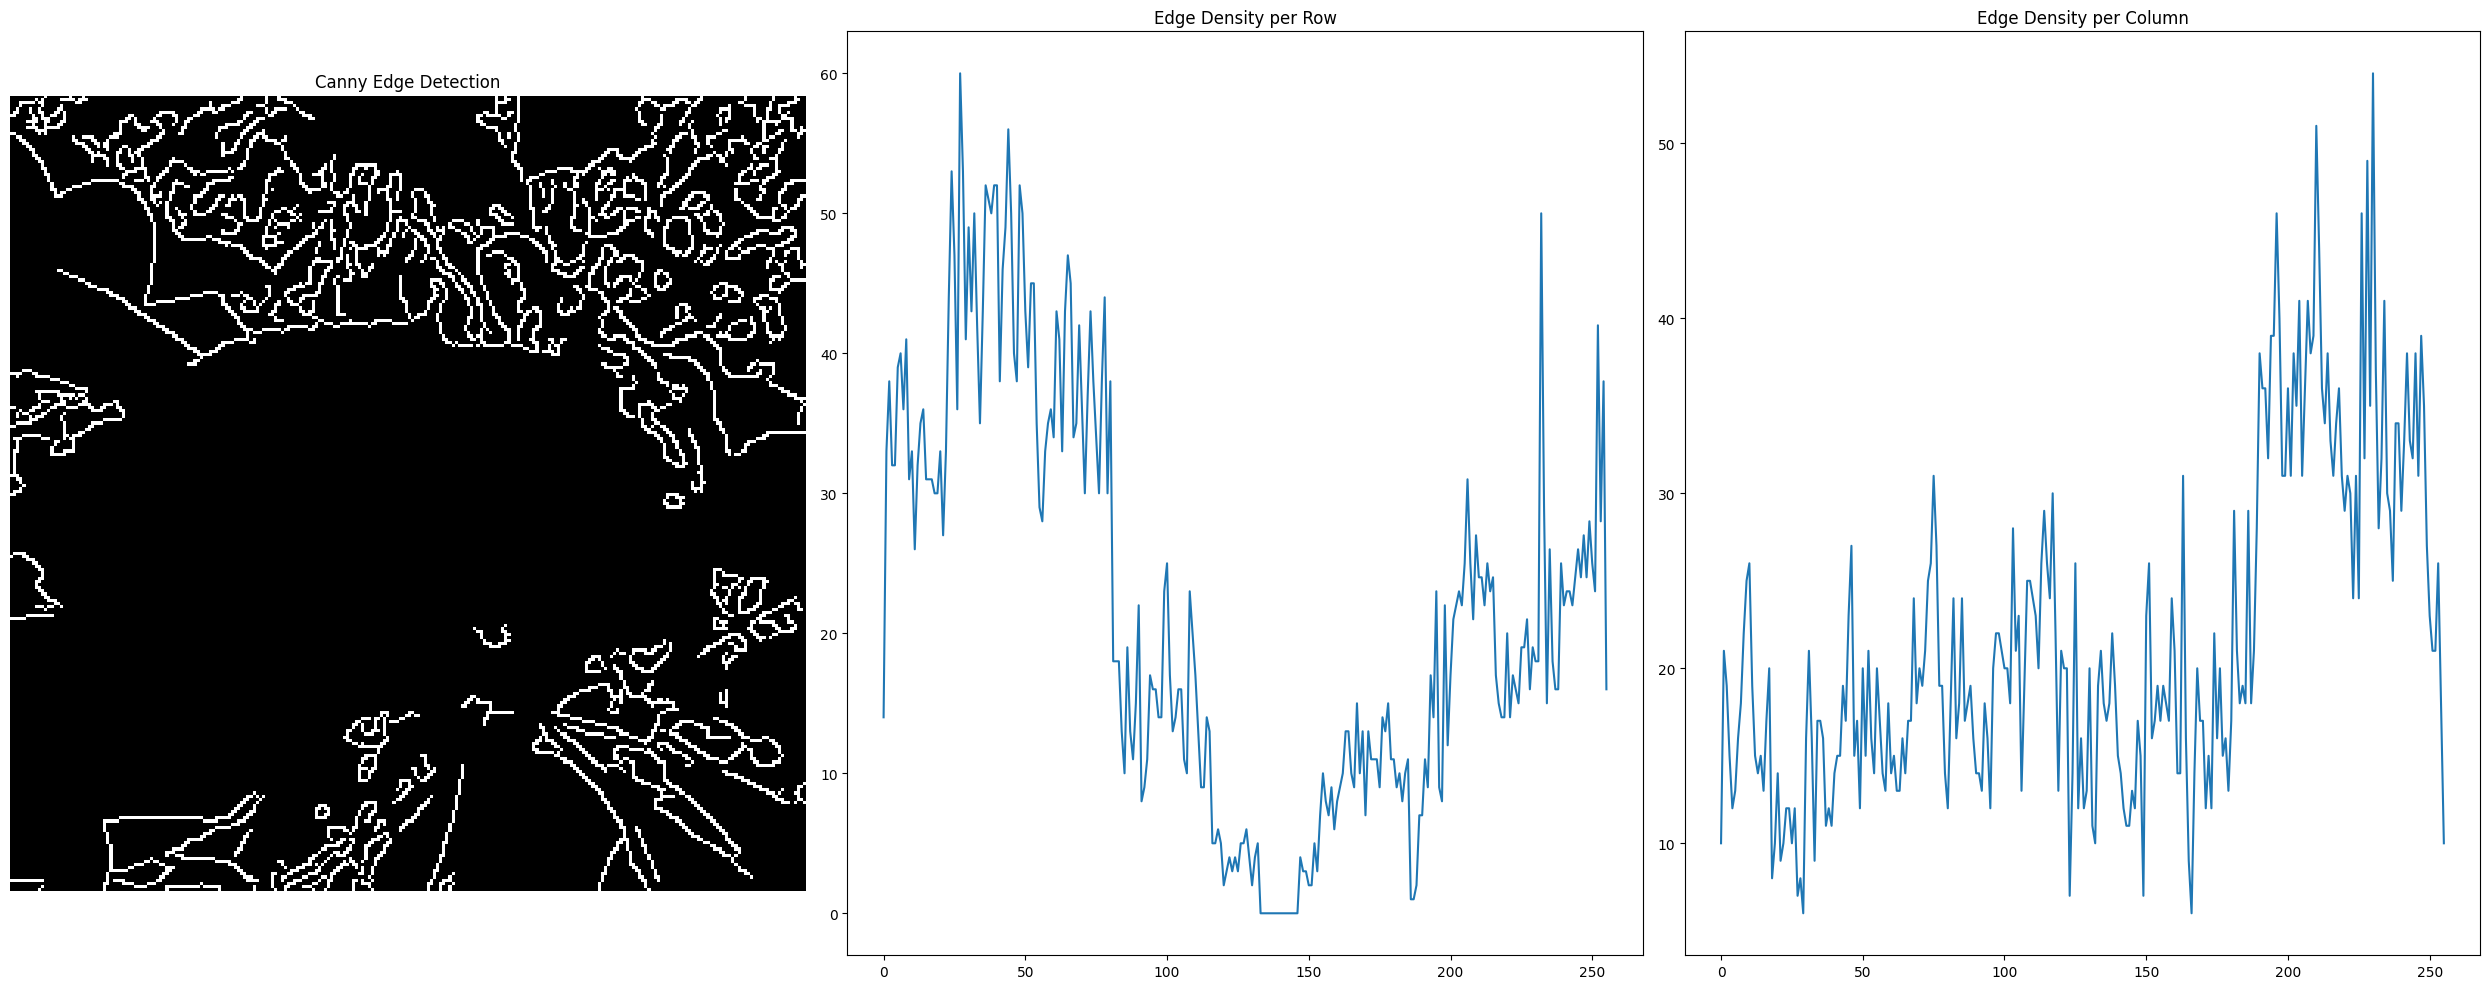

In [114]:
# extract random sample of images from each class in the training set
class_names = train.class_names

# Collect images by class
images_by_class = {name: [] for name in class_names}

# Iterate over individual samples
for img, label in train.unbatch():
    class_name = class_names[label.numpy()]
    images_by_class[class_name].append(img.numpy())

# Sample 1 random images from each class
healthy_image = random.choice(images_by_class["Healthy"])
powdery_image = random.choice(images_by_class["Powdery"])
rust_image = random.choice(images_by_class["Rust"])

# Canny Edge Detection - multistep algorithm uses Sobel as a component
img_gray = cv2.cvtColor(rust_image, cv2.COLOR_BGR2GRAY)
img_blur = cv2.GaussianBlur(img_gray, (3,3), 0)

edges = cv2.Canny(img_blur.astype("uint8"), threshold1=100, threshold2=200) # Canny Edge Detection

row_density = np.sum(edges == 255, axis=1)
col_density = np.sum(edges == 255, axis=0)

fig, axes = plt.subplots(1,3, figsize=(25,10))

# Show Canny edge image
axes[0].imshow(edges, cmap='gray')
axes[0].set_title('Canny Edge Detection')
axes[0].axis('off')

# count edges over rows/column
axes[1].plot(row_density)
axes[1].set_title("Edge Density per Row")
axes[2].plot(col_density)
axes[2].set_title("Edge Density per Column")

plt.tight_layout()
plt.show()

In [30]:
def compute_canny_fractions(images, threshold1=50, threshold2=150):
    """
    Apply Canny edge detection and return edge fractions
    (edge pixel count normalized by total pixels).
    """
    fractions = []
    for img in images:
        edges = cv2.Canny(img.astype(np.uint8), threshold1, threshold2)
        edge_count = np.count_nonzero(edges)
        total_pixels = img.shape[0] * img.shape[1]
        edge_fraction = edge_count / total_pixels
        fractions.append(edge_fraction)
    return np.array(fractions, dtype=np.float32)

In [70]:
# Compute fractions only
train_canny_features = compute_canny_fractions(train_images_processed)
val_canny_features = compute_canny_fractions(val_images_processed)
test_canny_features = compute_canny_fractions(test_images_processed)


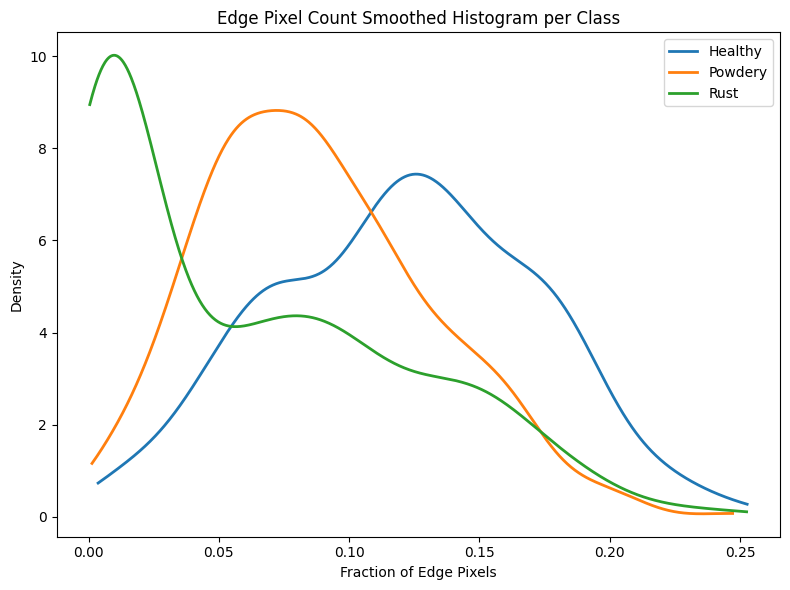

In [72]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.set_title('Edge Pixel Count Smoothed Histogram per Class')
ax.set_xlabel('Fraction of Edge Pixels')
ax.set_ylabel('Density')

class_names = ['Healthy', 'Powdery', 'Rust']

for i, label in enumerate(class_names):
    # Select edge pixel counts for this class
    class_edges = train_canny_features[train_labels == i]

    # Create an array of x-values for the smooth curve
    edge_x = np.linspace(class_edges.min(), class_edges.max(), 1000)

    # Calculate the KDE
    edge_kde = stats.gaussian_kde(class_edges)

    # Plot the smoothed density curve
    ax.plot(edge_x, edge_kde(edge_x), linewidth=2, label=label)

ax.legend()
plt.tight_layout()
plt.show()

### ResNet (CNN Feature Vector)

In [32]:
resnet_base = ResNet50(
    weights='imagenet',
    include_top=False,      # remove classification head
    pooling='avg',          # global average pooling → 2048-length vector
    input_shape=(224, 224, 3)
)

In [33]:
def extract_resnet_features(images, batch_size=32):
    """
    images: NumPy array of shape (N, H, W, 3), values in [0, 255] or [0, 1]
    returns: NumPy array of shape (N, 2048) with one feature vector per image
    """
    # Convert to float32
    images = images.astype("float32")

    # Resize to ResNet's expected input size (224x224)
    images_resized = tf.image.resize(images, (224, 224))

    # Apply ResNet preprocessing (mean subtraction, etc.)
    images_preprocessed = preprocess_input(images_resized)

    # Run through ResNet to get features
    features = resnet_base.predict(images_preprocessed, batch_size=batch_size, verbose=1)

    # features is already a NumPy array of shape (N, 2048)
    return features

In [105]:
train_cnn_features = extract_resnet_features(train_images, batch_size=32)
val_cnn_features = extract_resnet_features(val_images, batch_size=32)
test_cnn_features = extract_resnet_features(test_images, batch_size=32)

42/42 ━━━━━━━━━━━━━━━━━━━━ 18s 431ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 393ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 392ms/step


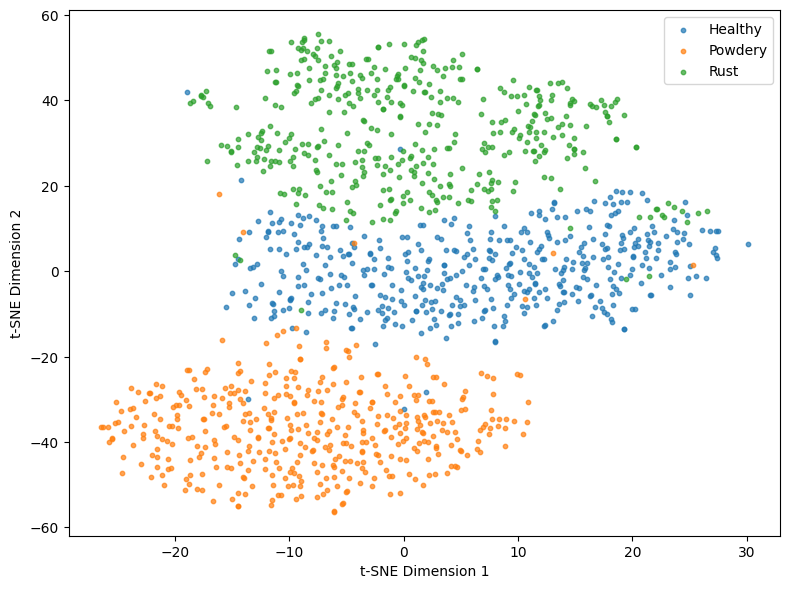

In [88]:
tsne = TSNE(
    n_components=2,
    perplexity=30,        # 5–50 usually reasonable
    learning_rate='auto',
    init='random',
    random_state=seed
)

# Input: (N_samples, 2048)
X_embedded = tsne.fit_transform(train_cnn_features)

# ================================
# Plotting
# ================================
plt.figure(figsize=(8, 6))
class_names = ['Healthy', 'Powdery', 'Rust']

for i, name in enumerate(class_names):
    mask = (train_labels == i)
    plt.scatter(
        X_embedded[mask, 0],
        X_embedded[mask, 1],
        s=10,
        alpha=0.7,
        label=name
    )

#plt.title('t-SNE of ResNet CNN Feature Vectors (Train Set)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend()
plt.tight_layout()
plt.show()

## Results

In [106]:
X_train = np.column_stack([train_blobs, train_blob_area, train_lumin, train_color_features, train_texture_features, train_canny_features, train_cnn_features])
X_train_simple = np.column_stack([train_blobs, train_blob_area, train_lumin, train_color_features, train_texture_features, train_canny_features])

X_val = np.column_stack([val_blobs, val_blob_area, val_lumin, val_color_features, valid_texture_features, val_canny_features, val_cnn_features])
X_val_simple = np.column_stack([val_blobs, val_blob_area, val_lumin, val_color_features, valid_texture_features, val_canny_features])

X_test = np.column_stack([test_blobs, test_blob_area, test_lumin, test_color_features, test_texture_features, test_canny_features, test_cnn_features])
X_test_simple = np.column_stack([test_blobs, test_blob_area, test_lumin, test_color_features, test_texture_features, test_canny_features])

classes = [0,1,2]

val_true_bin  = label_binarize(val_labels,  classes=classes)
test_true_bin = label_binarize(test_labels, classes=classes)

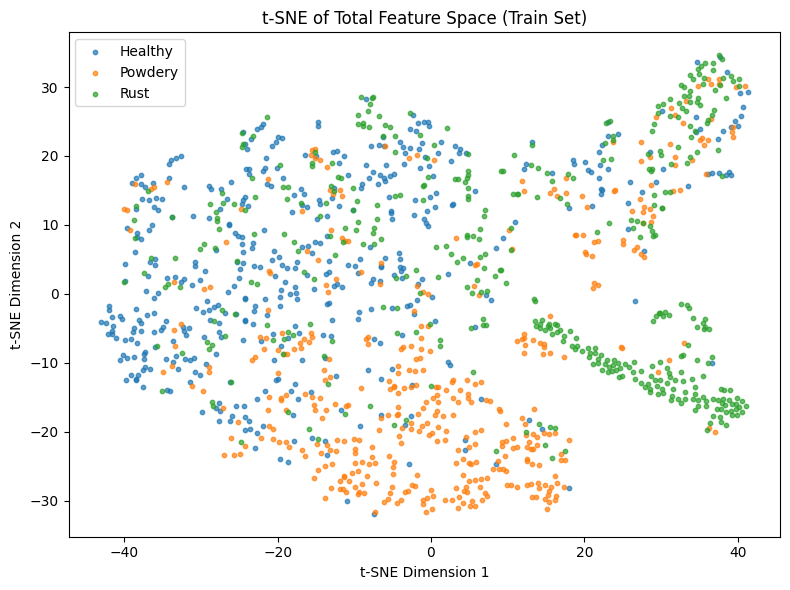

In [83]:
tsne = TSNE(
    n_components=2,
    perplexity=30,        # 5–50 usually reasonable
    learning_rate='auto',
    init='random',
    random_state=seed
)

# Input: (N_samples, 2048)
X_embedded = tsne.fit_transform(X_train)

# ================================
# Plotting
# ================================
plt.figure(figsize=(8, 6))
class_names = ['Healthy', 'Powdery', 'Rust']

for i, name in enumerate(class_names):
    mask = (train_labels == i)
    plt.scatter(
        X_embedded[mask, 0],
        X_embedded[mask, 1],
        s=10,
        alpha=0.7,
        label=name
    )

plt.title('t-SNE of Total Feature Space (Train Set)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend()
plt.tight_layout()
plt.show()

### Baseline

In [107]:
%%time
# Baseline toy classifier, feeding in grayscale images directly to a LR classifier

train_gray = np.array([cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) for img in train_images_processed])
val_gray = np.array([cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) for img in val_images_processed])
test_gray = np.array([cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) for img in test_images_processed])

# Flatten each image to shape (H*W,)
X_train_flat = train_gray.reshape(train_gray.shape[0], -1)
X_val_flat = val_gray.reshape(val_gray.shape[0], -1)
X_test_flat = test_gray.reshape(test_gray.shape[0], -1)

log_reg_flat = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000
)

log_reg_flat.fit(X_train_flat, train_labels)

train_pred_flat = log_reg_flat.predict(X_train_flat)
val_pred_flat = log_reg_flat.predict(X_val_flat)
test_pred_flat = log_reg_flat.predict(X_test_flat)

print("Baseline")
print("Train Results:")
print(classification_report(train_labels, train_pred_flat))
print("Validation Results:")
print(classification_report(val_labels, val_pred_flat))
print("Test Results:")
print(classification_report(test_labels, test_pred_flat))

classes = log_reg_flat.classes_

# Predicted probabilities
val_proba  = log_reg_flat.predict_proba(X_val_flat)
test_proba = log_reg_flat.predict_proba(X_test_flat)

# Macro-average AUC across classes
val_auc  = roc_auc_score(val_true_bin,  val_proba,  average='macro', multi_class='ovr')
test_auc = roc_auc_score(test_true_bin, test_proba, average='macro', multi_class='ovr')

print(f"\nAverage AUC (macro) on validation set: {val_auc:.4f}")
print(f"Average AUC (macro) on test set: {test_auc:.4f}")

Baseline
Train Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       458
           1       1.00      1.00      1.00       430
           2       1.00      1.00      1.00       434

    accuracy                           1.00      1322
   macro avg       1.00      1.00      1.00      1322
weighted avg       1.00      1.00      1.00      1322

Validation Results:
              precision    recall  f1-score   support

           0       0.62      0.65      0.63        20
           1       0.38      0.40      0.39        20
           2       0.28      0.25      0.26        20

    accuracy                           0.43        60
   macro avg       0.43      0.43      0.43        60
weighted avg       0.43      0.43      0.43        60

Test Results:
              precision    recall  f1-score   support

           0       0.44      0.62      0.52        50
           1       0.48      0.40      0.43        50
           2     

### LR

In [108]:
%%time
# Untuned LR simple

log_reg = LogisticRegression(
    solver='lbfgs',
    max_iter=2000
)

# Fit on 2D feature matrix
log_reg.fit(X_train_simple, train_labels)

val_pred_lr_untuned_simple = log_reg.predict(X_val_simple)
test_pred_lr_untuned_simple = log_reg.predict(X_test_simple)

print("LR Untuned Simple")
print("Validation Results:")
print(classification_report(val_labels, val_pred_lr_untuned_simple))
print("Test Results:")
print(classification_report(test_labels, test_pred_lr_untuned_simple))

classes = log_reg.classes_

# Predicted probabilities
val_proba  = log_reg.predict_proba(X_val_simple)
test_proba = log_reg.predict_proba(X_test_simple)

# Macro-average AUC across classes
val_auc  = roc_auc_score(val_true_bin,  val_proba,  average='macro', multi_class='ovr')
test_auc = roc_auc_score(test_true_bin, test_proba, average='macro', multi_class='ovr')

print(f"\nAverage AUC (macro) on validation set: {val_auc:.4f}")
print(f"Average AUC (macro) on test set: {test_auc:.4f}")

LR Untuned Simple
Validation Results:
              precision    recall  f1-score   support

           0       0.67      0.60      0.63        20
           1       0.78      0.90      0.84        20
           2       0.79      0.75      0.77        20

    accuracy                           0.75        60
   macro avg       0.75      0.75      0.75        60
weighted avg       0.75      0.75      0.75        60

Test Results:
              precision    recall  f1-score   support

           0       0.71      0.70      0.71        50
           1       0.79      0.76      0.78        50
           2       0.70      0.74      0.72        50

    accuracy                           0.73       150
   macro avg       0.73      0.73      0.73       150
weighted avg       0.73      0.73      0.73       150


Average AUC (macro) on validation set: 0.9350
Average AUC (macro) on test set: 0.8852
CPU times: total: 2.58 s
Wall time: 1.07 s


In [103]:
%%time
# Untuned LR

log_reg = LogisticRegression(
    solver='lbfgs',
    max_iter=2000
)

# Fit on 2D feature matrix
log_reg.fit(X_train, train_labels)

val_pred_lr_untuned = log_reg.predict(X_val)
test_pred_lr_untuned = log_reg.predict(X_test)

print("LR Untuned")
print("Validation Results:")
print(classification_report(val_labels, val_pred_lr_untuned))
print("Test Results:")
print(classification_report(test_labels, test_pred_lr_untuned))

classes = log_reg.classes_

# Predicted probabilities
val_proba  = log_reg.predict_proba(X_val)
test_proba = log_reg.predict_proba(X_test)

# Macro-average AUC across classes
val_auc  = roc_auc_score(val_true_bin,  val_proba,  average='macro', multi_class='ovr')
test_auc = roc_auc_score(test_true_bin, test_proba, average='macro', multi_class='ovr')

print(f"\nAverage AUC (macro) on validation set: {val_auc:.4f}")
print(f"Average AUC (macro) on test set: {test_auc:.4f}")

LR Untuned
Validation Results:
              precision    recall  f1-score   support

           0       0.76      0.80      0.78        20
           1       0.95      0.90      0.92        20
           2       0.85      0.85      0.85        20

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.85      0.85      0.85        60

Test Results:
              precision    recall  f1-score   support

           0       0.76      0.84      0.80        50
           1       0.80      0.78      0.79        50
           2       0.78      0.72      0.75        50

    accuracy                           0.78       150
   macro avg       0.78      0.78      0.78       150
weighted avg       0.78      0.78      0.78       150


Average AUC (macro) on validation set: 0.9633
Average AUC (macro) on test set: 0.9313
CPU times: total: 47.4 s
Wall time: 4.76 s


In [40]:
%%time
# Tuned LR simple

log_reg = LogisticRegression(
    solver='lbfgs',   # supports multinomial + l2
    max_iter=2000
)

# Hyperparameter grid to search over
param_grid = {
    "C": [0.01, 0.1, 1, 10]
}

# Grid search with 5-fold CV, optimizing accuracy
grid = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,        # use all cores
    verbose=1
)

# Fit grid search on training data
grid.fit(X_train_simple, train_labels)

print("Best hyperparameters:", grid.best_params_)
print(f"Best CV accuracy: {grid.best_score_:.4f}")

# Use the best model to predict on validation set
best_log_reg = grid.best_estimator_
val_pred_lr_simple = best_log_reg.predict(X_val_simple)
test_pred_lr_simple = best_log_reg.predict(X_test_simple)

print("LR Tuned Simple")
print("Validation Results:")
print(classification_report(val_labels, val_pred_lr_simple))
print("Test Results:")
print(classification_report(test_labels, test_pred_lr_simple))

classes = best_log_reg.classes_

# Predicted probabilities
val_proba  = best_log_reg.predict_proba(X_val_simple)
test_proba = best_log_reg.predict_proba(X_test_simple)

# Macro-average AUC across classes
val_auc  = roc_auc_score(val_true_bin,  val_proba,  average='macro', multi_class='ovr')
test_auc = roc_auc_score(test_true_bin, test_proba, average='macro', multi_class='ovr')

print(f"\nAverage AUC (macro) on validation set: {val_auc:.4f}")
print(f"Average AUC (macro) on test set: {test_auc:.4f}")

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best hyperparameters: {'C': 0.01}
Best CV accuracy: 0.7746
LR Tuned Simple
Validation Results:
              precision    recall  f1-score   support

           0       0.68      0.65      0.67        20
           1       0.75      0.90      0.82        20
           2       0.82      0.70      0.76        20

    accuracy                           0.75        60
   macro avg       0.75      0.75      0.75        60
weighted avg       0.75      0.75      0.75        60

Test Results:
              precision    recall  f1-score   support

           0       0.72      0.68      0.70        50
           1       0.76      0.76      0.76        50
           2       0.70      0.74      0.72        50

    accuracy                           0.73       150
   macro avg       0.73      0.73      0.73       150
weighted avg       0.73      0.73      0.73       150


Average AUC (macro) on validation set: 0.9367
Average AUC (macro) on

In [41]:
%%time
# Tuned LR

log_reg = LogisticRegression(
    solver='lbfgs',   # supports multinomial + l2
    max_iter=2000
)

# Hyperparameter grid to search over
param_grid = {
    "C": [0.01, 0.1, 1, 10]
}

# Grid search with 5-fold CV, optimizing accuracy
grid = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,        # use all cores
    verbose=1
)

# Fit grid search on training data
grid.fit(X_train, train_labels)

print("Best hyperparameters:", grid.best_params_)
print(f"Best CV accuracy: {grid.best_score_:.4f}")

# Use the best model to predict on validation set
best_log_reg = grid.best_estimator_
val_pred_lr = best_log_reg.predict(X_val)
test_pred_lr = best_log_reg.predict(X_test)

print("LR Tuned")
print("Validation Results:")
print(classification_report(val_labels, val_pred_lr))
print("Test Results:")
print(classification_report(test_labels, test_pred_lr))

classes = best_log_reg.classes_

# Predicted probabilities
val_proba  = best_log_reg.predict_proba(X_val)
test_proba = best_log_reg.predict_proba(X_test)

# Macro-average AUC across classes
val_auc  = roc_auc_score(val_true_bin,  val_proba,  average='macro', multi_class='ovr')
test_auc = roc_auc_score(test_true_bin, test_proba, average='macro', multi_class='ovr')

print(f"\nAverage AUC (macro) on validation set: {val_auc:.4f}")
print(f"Average AUC (macro) on test set: {test_auc:.4f}")

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best hyperparameters: {'C': 0.01}
Best CV accuracy: 0.8721
LR Tuned
Validation Results:
              precision    recall  f1-score   support

           0       0.74      0.85      0.79        20
           1       0.95      0.90      0.92        20
           2       0.89      0.80      0.84        20

    accuracy                           0.85        60
   macro avg       0.86      0.85      0.85        60
weighted avg       0.86      0.85      0.85        60

Test Results:
              precision    recall  f1-score   support

           0       0.77      0.86      0.81        50
           1       0.89      0.82      0.85        50
           2       0.85      0.82      0.84        50

    accuracy                           0.83       150
   macro avg       0.84      0.83      0.83       150
weighted avg       0.84      0.83      0.83       150


Average AUC (macro) on validation set: 0.9767
Average AUC (macro) on test s

### SVC

In [42]:
%%time
# Untuned SVC simple

svc = SVC(
    kernel='rbf',         # 'rbf' or 'linear', 'poly', 'sigmoid'
    C=1.0,                # regularization strength
    gamma='scale',        # kernel coefficient
    probability=True,     # enables predict_proba (needed for ROC curves)
    decision_function_shape='ovr'  # One-vs-Rest multiclass scheme
)

# Train the model
svc.fit(X_train_simple, train_labels)

val_pred_svc_untuned_simple = svc.predict(X_val_simple)
test_pred_svc_untuned_simple = svc.predict(X_test_simple)

print("SVC Untuned Simple")
print("Validation Results:")
print(classification_report(val_labels, val_pred_svc_untuned_simple))
print("Test Results:")
print(classification_report(test_labels, test_pred_svc_untuned_simple))

classes = svc.classes_

# Predicted probabilities
val_proba  = svc.predict_proba(X_val_simple)
test_proba = svc.predict_proba(X_test_simple)

# Macro-average AUC across classes
val_auc  = roc_auc_score(val_true_bin,  val_proba,  average='macro', multi_class='ovr')
test_auc = roc_auc_score(test_true_bin, test_proba, average='macro', multi_class='ovr')

print(f"\nAverage AUC (macro) on validation set: {val_auc:.4f}")
print(f"Average AUC (macro) on test set: {test_auc:.4f}")


SVC Untuned Simple
Validation Results:
              precision    recall  f1-score   support

           0       0.76      0.80      0.78        20
           1       0.84      0.80      0.82        20
           2       0.80      0.80      0.80        20

    accuracy                           0.80        60
   macro avg       0.80      0.80      0.80        60
weighted avg       0.80      0.80      0.80        60

Test Results:
              precision    recall  f1-score   support

           0       0.56      0.82      0.67        50
           1       0.79      0.62      0.70        50
           2       0.74      0.56      0.64        50

    accuracy                           0.67       150
   macro avg       0.70      0.67      0.67       150
weighted avg       0.70      0.67      0.67       150


Average AUC (macro) on validation set: 0.9388
Average AUC (macro) on test set: 0.8507
CPU times: total: 469 ms
Wall time: 485 ms


In [43]:
%%time
# Untuned SVC

svc = SVC(
    kernel='rbf',         # 'rbf' or 'linear', 'poly', 'sigmoid'
    C=1.0,                # regularization strength
    gamma='scale',        # kernel coefficient
    probability=True,     # enables predict_proba (needed for ROC curves)
    decision_function_shape='ovr'  # One-vs-Rest multiclass scheme
)

# Train the model
svc.fit(X_train, train_labels)

val_pred_svc_untuned = svc.predict(X_val)
test_pred_svc_untuned = svc.predict(X_test)

print("SVC Untuned")
print("Validation Results:")
print(classification_report(val_labels, val_pred_svc_untuned))
print("Test Results:")
print(classification_report(test_labels, test_pred_svc_untuned))

classes = svc.classes_

# Predicted probabilities
val_proba  = svc.predict_proba(X_val)
test_proba = svc.predict_proba(X_test)

# Macro-average AUC across classes
val_auc  = roc_auc_score(val_true_bin,  val_proba,  average='macro', multi_class='ovr')
test_auc = roc_auc_score(test_true_bin, test_proba, average='macro', multi_class='ovr')

print(f"\nAverage AUC (macro) on validation set: {val_auc:.4f}")
print(f"Average AUC (macro) on test set: {test_auc:.4f}")

SVC Untuned
Validation Results:
              precision    recall  f1-score   support

           0       0.73      0.80      0.76        20
           1       0.83      0.75      0.79        20
           2       0.75      0.75      0.75        20

    accuracy                           0.77        60
   macro avg       0.77      0.77      0.77        60
weighted avg       0.77      0.77      0.77        60

Test Results:
              precision    recall  f1-score   support

           0       0.55      0.82      0.66        50
           1       0.79      0.62      0.70        50
           2       0.73      0.54      0.62        50

    accuracy                           0.66       150
   macro avg       0.69      0.66      0.66       150
weighted avg       0.69      0.66      0.66       150


Average AUC (macro) on validation set: 0.9392
Average AUC (macro) on test set: 0.8490
CPU times: total: 3.11 s
Wall time: 3.13 s


In [44]:
%%time
# Tuned SVC simple

svc = SVC(
    probability=True,              # keep this so we can use predict_proba later
    decision_function_shape='ovr'  # One-vs-Rest
)

# Hyperparameter grid
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", "auto"],
    "kernel": ["rbf", "linear"]
}

# Grid search with 5-fold cross-validation
grid_svc = GridSearchCV(
    estimator=svc,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit grid search on training data
grid_svc.fit(X_train_simple, train_labels)

print("Best hyperparameters:", grid_svc.best_params_)
print(f"Best CV accuracy: {grid_svc.best_score_:.4f}")

# Use the best-found model
best_svc = grid_svc.best_estimator_

val_pred_svc_simple = best_svc.predict(X_val_simple)
test_pred_svc_simple = best_svc.predict(X_test_simple)

print("SVC Tuned Simple")
print("Validation Results:")
print(classification_report(val_labels, val_pred_svc_simple))
print("Test Results:")
print(classification_report(test_labels, test_pred_svc_simple))

classes = best_svc.classes_

# Predicted probabilities
val_proba  = best_svc.predict_proba(X_val_simple)
test_proba = best_svc.predict_proba(X_test_simple)

# Macro-average AUC across classes
val_auc  = roc_auc_score(val_true_bin,  val_proba,  average='macro', multi_class='ovr')
test_auc = roc_auc_score(test_true_bin, test_proba, average='macro', multi_class='ovr')

print(f"\nAverage AUC (macro) on validation set: {val_auc:.4f}")
print(f"Average AUC (macro) on test set: {test_auc:.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best hyperparameters: {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV accuracy: 0.7610
SVC Tuned Simple
Validation Results:
              precision    recall  f1-score   support

           0       0.73      0.80      0.76        20
           1       0.80      0.80      0.80        20
           2       0.83      0.75      0.79        20

    accuracy                           0.78        60
   macro avg       0.79      0.78      0.78        60
weighted avg       0.79      0.78      0.78        60

Test Results:
              precision    recall  f1-score   support

           0       0.71      0.84      0.77        50
           1       0.81      0.78      0.80        50
           2       0.77      0.66      0.71        50

    accuracy                           0.76       150
   macro avg       0.76      0.76      0.76       150
weighted avg       0.76      0.76      0.76       150


Average AUC (macro) on validatio

In [45]:
%%time
# Tuned SVC

svc = SVC(
    probability=True,              # keep this so we can use predict_proba later
    decision_function_shape='ovr'  # One-vs-Rest
)

# Hyperparameter grid
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", "auto"],
    "kernel": ["rbf", "linear"]
}

# Grid search with 5-fold cross-validation
grid_svc = GridSearchCV(
    estimator=svc,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit grid search on training data
grid_svc.fit(X_train, train_labels)

print("Best hyperparameters:", grid_svc.best_params_)
print(f"Best CV accuracy: {grid_svc.best_score_:.4f}")

# Use the best-found model
best_svc = grid_svc.best_estimator_

val_pred_svc = best_svc.predict(X_val)
test_pred_svc = best_svc.predict(X_test)

print("SVC Tuned")
print("Validation Results:")
print(classification_report(val_labels, val_pred_svc))
print("Test Results:")
print(classification_report(test_labels, test_pred_svc))

classes = best_svc.classes_

# Predicted probabilities
val_proba  = best_svc.predict_proba(X_val)
test_proba = best_svc.predict_proba(X_test)

# Macro-average AUC across classes
val_auc  = roc_auc_score(val_true_bin,  val_proba,  average='macro', multi_class='ovr')
test_auc = roc_auc_score(test_true_bin, test_proba, average='macro', multi_class='ovr')

print(f"\nAverage AUC (macro) on validation set: {val_auc:.4f}")
print(f"Average AUC (macro) on test set: {test_auc:.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best hyperparameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best CV accuracy: 0.8615
SVC Tuned
Validation Results:
              precision    recall  f1-score   support

           0       0.75      0.90      0.82        20
           1       0.95      0.95      0.95        20
           2       0.94      0.75      0.83        20

    accuracy                           0.87        60
   macro avg       0.88      0.87      0.87        60
weighted avg       0.88      0.87      0.87        60

Test Results:
              precision    recall  f1-score   support

           0       0.80      0.82      0.81        50
           1       0.80      0.82      0.81        50
           2       0.79      0.76      0.78        50

    accuracy                           0.80       150
   macro avg       0.80      0.80      0.80       150
weighted avg       0.80      0.80      0.80       150


Average AUC (macro) on validation se

### RF

In [95]:
%%time
# Untuned RF simple

rf = RandomForestClassifier(
    n_estimators=200,    # number of trees
    max_depth=None,     # allow trees to grow fully
    random_state=seed,    # reproducible results
    class_weight=None
)

# Train the model
rf.fit(X_train_simple, train_labels)

val_pred_rf_untuned_simple = rf.predict(X_val_simple)
test_pred_rf_untuned_simple = rf.predict(X_test_simple)

print("RF Untuned Simple")
print("Validation Results:")
print(classification_report(val_labels, val_pred_rf_untuned_simple))
print("Test Results:")
print(classification_report(test_labels, test_pred_rf_untuned_simple))

classes = rf.classes_

# Predicted probabilities
val_proba  = rf.predict_proba(X_val_simple)
test_proba = rf.predict_proba(X_test_simple)

# Macro-average AUC across classes
val_auc  = roc_auc_score(val_true_bin,  val_proba,  average='macro', multi_class='ovr')
test_auc = roc_auc_score(test_true_bin, test_proba, average='macro', multi_class='ovr')

print(f"\nAverage AUC (macro) on validation set: {val_auc:.4f}")
print(f"Average AUC (macro) on test set: {test_auc:.4f}")

RF Untuned Simple
Validation Results:
              precision    recall  f1-score   support

           0       0.74      0.85      0.79        20
           1       0.90      0.90      0.90        20
           2       0.82      0.70      0.76        20

    accuracy                           0.82        60
   macro avg       0.82      0.82      0.82        60
weighted avg       0.82      0.82      0.82        60

Test Results:
              precision    recall  f1-score   support

           0       0.65      0.90      0.76        50
           1       0.84      0.74      0.79        50
           2       0.78      0.58      0.67        50

    accuracy                           0.74       150
   macro avg       0.76      0.74      0.74       150
weighted avg       0.76      0.74      0.74       150


Average AUC (macro) on validation set: 0.9615
Average AUC (macro) on test set: 0.9169
CPU times: total: 1.75 s
Wall time: 1.81 s


In [109]:
%%time
# Untuned RF

rf = RandomForestClassifier(
    n_estimators=100,    # number of trees
    max_depth=None,     # allow trees to grow fully
    random_state=seed,    # reproducible results
    class_weight=None
)

# Train the model
rf.fit(X_train, train_labels)

val_pred_rf_untuned = rf.predict(X_val)
test_pred_rf_untuned = rf.predict(X_test)

print("RF Untuned")
print("Validation Results:")
print(classification_report(val_labels, val_pred_rf_untuned))
print("Test Results:")
print(classification_report(test_labels, test_pred_rf_untuned))

classes = rf.classes_

# Predicted probabilities
val_proba  = rf.predict_proba(X_val)
test_proba = rf.predict_proba(X_test)

# Macro-average AUC across classes
val_auc  = roc_auc_score(val_true_bin,  val_proba,  average='macro', multi_class='ovr')
test_auc = roc_auc_score(test_true_bin, test_proba, average='macro', multi_class='ovr')

print(f"\nAverage AUC (macro) on validation set: {val_auc:.4f}")
print(f"Average AUC (macro) on test set: {test_auc:.4f}")

RF Untuned
Validation Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      1.00      1.00        20

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60

Test Results:
              precision    recall  f1-score   support

           0       0.91      0.96      0.93        50
           1       0.98      0.90      0.94        50
           2       0.96      0.98      0.97        50

    accuracy                           0.95       150
   macro avg       0.95      0.95      0.95       150
weighted avg       0.95      0.95      0.95       150


Average AUC (macro) on validation set: 1.0000
Average AUC (macro) on test set: 0.9925
CPU times: total: 1.94 s
Wall time: 1.95 s


In [48]:
%%time
# Tuned RF simple

rf = RandomForestClassifier(
    random_state=seed,
    class_weight=None
)

# Parameter grid for Random Forest
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# Grid search
grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit on training data
grid_rf.fit(X_train_simple, train_labels)

print("Best hyperparameters:", grid_rf.best_params_)
print(f"Best CV accuracy: {grid_rf.best_score_:.4f}")

# Best model
best_rf = grid_rf.best_estimator_

val_pred_rf_simple = best_rf.predict(X_val_simple)
test_pred_rf_simple = best_rf.predict(X_test_simple)

print("RF Tuned Simple")
print("Validation Results:")
print(classification_report(val_labels, val_pred_rf_simple))
print("Test Results:")
print(classification_report(test_labels, test_pred_rf_simple))

classes = best_rf.classes_

# Predicted probabilities
val_proba  = best_rf.predict_proba(X_val_simple)
test_proba = best_rf.predict_proba(X_test_simple)

# Macro-average AUC across classes
val_auc  = roc_auc_score(val_true_bin,  val_proba,  average='macro', multi_class='ovr')
test_auc = roc_auc_score(test_true_bin, test_proba, average='macro', multi_class='ovr')

print(f"\nAverage AUC (macro) on validation set: {val_auc:.4f}")
print(f"Average AUC (macro) on test set: {test_auc:.4f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best hyperparameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best CV accuracy: 0.7753
RF Tuned Simple
Validation Results:
              precision    recall  f1-score   support

           0       0.75      0.90      0.82        20
           1       0.90      0.90      0.90        20
           2       0.88      0.70      0.78        20

    accuracy                           0.83        60
   macro avg       0.84      0.83      0.83        60
weighted avg       0.84      0.83      0.83        60

Test Results:
              precision    recall  f1-score   support

           0       0.64      0.90      0.75        50
           1       0.86      0.72      0.78        50
           2       0.79      0.60      0.68        50

    accuracy                           0.74       150
   macro avg       0.76      0.74      0.74       150
weighted avg       0.76      0.74      0.74   

In [49]:
%%time
# Tuned RF

rf = RandomForestClassifier(
    random_state=seed,
    class_weight=None
)

# Parameter grid for Random Forest
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# Grid search
grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit on training data
grid_rf.fit(X_train, train_labels)

print("Best hyperparameters:", grid_rf.best_params_)
print(f"Best CV accuracy: {grid_rf.best_score_:.4f}")

# Best model
best_rf = grid_rf.best_estimator_

val_pred_rf = best_rf.predict(X_val)
test_pred_rf = best_rf.predict(X_test)

print("RF Tuned")
print("Validation Results:")
print(classification_report(val_labels, val_pred_rf))
print("Test Results:")
print(classification_report(test_labels, test_pred_rf))

classes = best_rf.classes_

# Predicted probabilities
val_proba  = best_rf.predict_proba(X_val)
test_proba = best_rf.predict_proba(X_test)

# Macro-average AUC across classes
val_auc  = roc_auc_score(val_true_bin,  val_proba,  average='macro', multi_class='ovr')
test_auc = roc_auc_score(test_true_bin, test_proba, average='macro', multi_class='ovr')

print(f"\nAverage AUC (macro) on validation set: {val_auc:.4f}")
print(f"Average AUC (macro) on test set: {test_auc:.4f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best hyperparameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best CV accuracy: 0.9818
RF Tuned
Validation Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      1.00      1.00        20

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60

Test Results:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94        50
           1       1.00      0.90      0.95        50
           2       0.98      1.00      0.99        50

    accuracy                           0.96       150
   macro avg       0.96      0.96      0.96       150
weighted avg       0.96      0.96      0.96       150

### Visualizations

#### Confusion Matrices

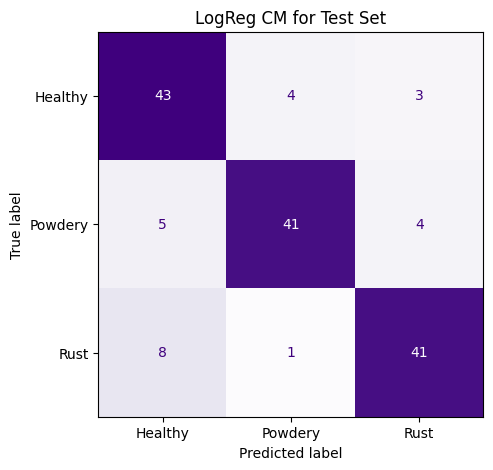

In [50]:
class_names = ["Healthy", "Powdery", "Rust"]
cm = confusion_matrix(test_labels, test_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Purples", values_format="d", colorbar=False)
plt.title("LogReg CM for Test Set")
plt.show()

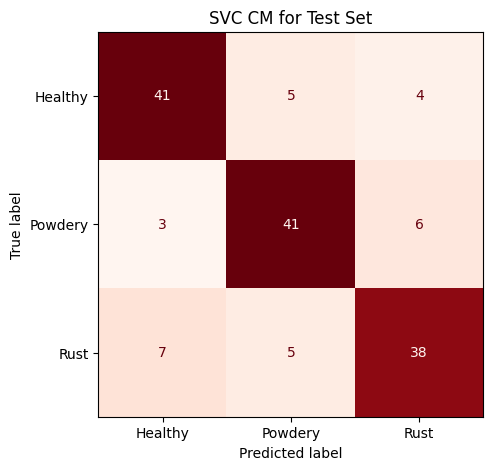

In [51]:
class_names = ["Healthy", "Powdery", "Rust"]
cm = confusion_matrix(test_labels, test_pred_svc)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Reds", values_format="d", colorbar=False)
plt.title("SVC CM for Test Set")
plt.show()

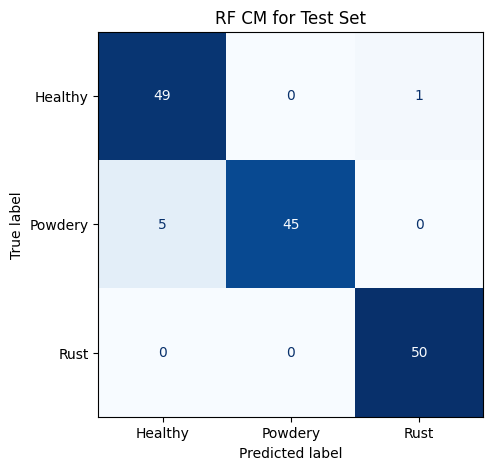

In [52]:
class_names = ["Healthy", "Powdery", "Rust"]
cm = confusion_matrix(test_labels, test_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
plt.title("RF CM for Test Set")
plt.show()

#### ROC Curves

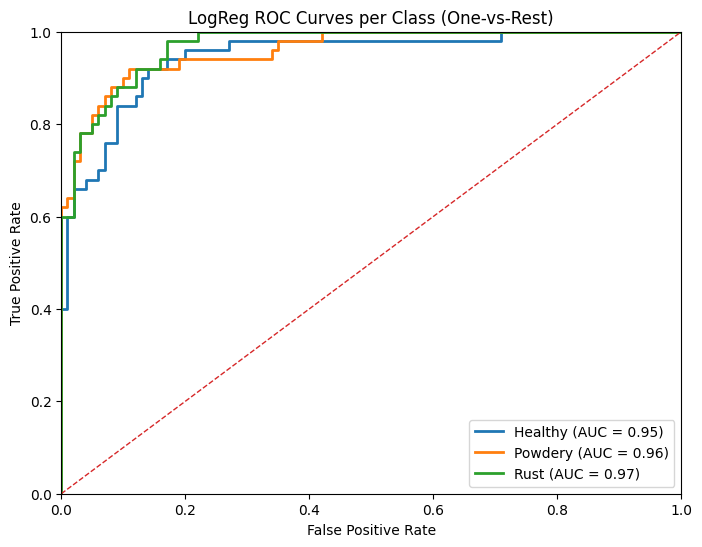

AUC for class 0: 0.9460
AUC for class 1: 0.9600
AUC for class 2: 0.9698


In [53]:
y_score = best_log_reg.predict_proba(X_test)  # shape: (n_samples, n_classes)

# Binarize the true labels: one-vs-rest
classes = best_log_reg.classes_               # ensures same order as columns of y_score
y_true_bin = label_binarize(test_labels, classes=classes)  # shape: (n_samples, n_classes)

# Prepare plot
plt.figure(figsize=(8, 6))

auc_per_class = {}

for i, cls in enumerate(classes):
    # ROC for this class vs rest
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    auc_per_class[cls] = roc_auc

    plt.plot(fpr, tpr, lw=2, label=f"{class_names[i]} (AUC = {roc_auc:.2f})")

# Diagonal line for random classifier
plt.plot([0, 1], [0, 1], linestyle="--", lw=1)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("LogReg ROC Curves per Class (One-vs-Rest)")
plt.legend(loc="lower right")
plt.show()

# Print AUC per class
for cls, cls_auc in auc_per_class.items():
    print(f"AUC for class {cls}: {cls_auc:.4f}")

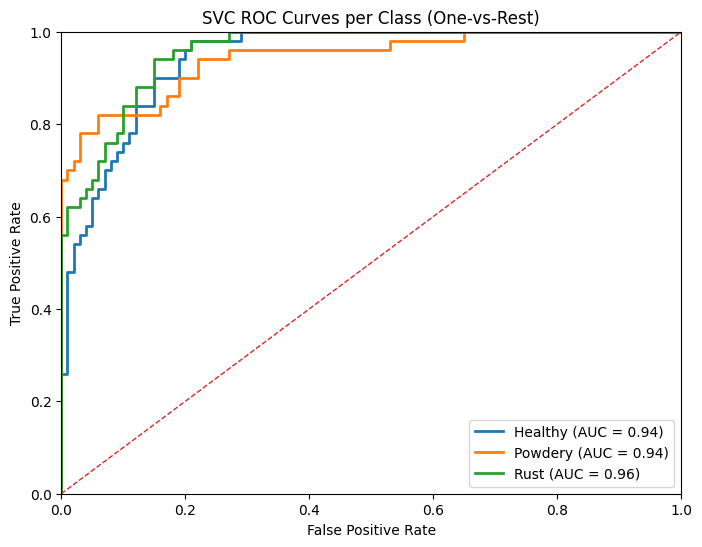

AUC for class 0: 0.9428
AUC for class 1: 0.9432
AUC for class 2: 0.9570


In [54]:
y_score = best_svc.predict_proba(X_test)  # shape: (n_samples, n_classes)

# Binarize the true labels: one-vs-rest
classes = best_svc.classes_               # ensures same order as columns of y_score
y_true_bin = label_binarize(test_labels, classes=classes)  # shape: (n_samples, n_classes)

# Prepare plot
plt.figure(figsize=(8, 6))

auc_per_class = {}

for i, cls in enumerate(classes):
    # ROC for this class vs rest
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    auc_per_class[cls] = roc_auc

    plt.plot(fpr, tpr, lw=2, label=f"{class_names[i]} (AUC = {roc_auc:.2f})")

# Diagonal line for random classifier
plt.plot([0, 1], [0, 1], linestyle="--", lw=1)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVC ROC Curves per Class (One-vs-Rest)")
plt.legend(loc="lower right")
plt.show()

# Print AUC per class
for cls, cls_auc in auc_per_class.items():
    print(f"AUC for class {cls}: {cls_auc:.4f}")

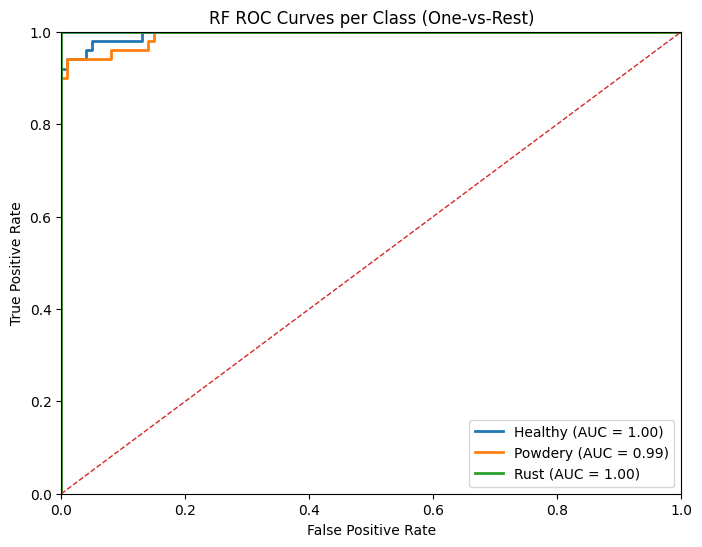

AUC for class 0: 0.9954
AUC for class 1: 0.9922
AUC for class 2: 1.0000


In [55]:
y_score = best_rf.predict_proba(X_test)  # shape: (n_samples, n_classes)

# Binarize the true labels: one-vs-rest
classes = best_rf.classes_               # ensures same order as columns of y_score
y_true_bin = label_binarize(test_labels, classes=classes)  # shape: (n_samples, n_classes)

# Prepare plot
plt.figure(figsize=(8, 6))

auc_per_class = {}

for i, cls in enumerate(classes):
    # ROC for this class vs rest
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    auc_per_class[cls] = roc_auc

    plt.plot(fpr, tpr, lw=2, label=f"{class_names[i]} (AUC = {roc_auc:.2f})")

# Diagonal line for random classifier
plt.plot([0, 1], [0, 1], linestyle="--", lw=1)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("RF ROC Curves per Class (One-vs-Rest)")
plt.legend(loc="lower right")
plt.show()

# Print AUC per class
for cls, cls_auc in auc_per_class.items():
    print(f"AUC for class {cls}: {cls_auc:.4f}")